In [1]:
# Important libraries - Load this block of code before anything else
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModelForImageClassification
from torch.nn.functional import softmax
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay

The **validation dataset** is currently not complete. For now, we need to work on individual image entries.

In [2]:
# SMOGY MODEL
processor1 = AutoImageProcessor.from_pretrained("Smogy/SMOGY-Ai-images-detector")
model1 = AutoModelForImageClassification.from_pretrained("Smogy/SMOGY-Ai-images-detector")
model1.load_state_dict(torch.load('./models/mirage_smogy_ai_detection/fine_tuned_smogy_model.pt'))
print("Model and processor 1 loaded successfully.")

Loading weights:   0%|          | 0/449 [00:00<?, ?it/s]

Model and processor 1 loaded successfully.


In [3]:
# ATEEQQ MODEL
processor2 = AutoImageProcessor.from_pretrained("./models/mirage_ateeqq_ai_vs_human_detector")
model2 = AutoModelForImageClassification.from_pretrained("./models/mirage_ateeqq_ai_vs_human_detector")
print("Model and processor 2 loaded successfully.")

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Model and processor 2 loaded successfully.


In [4]:
# PRITHIV (deepfake) MODEL
processor3 = AutoImageProcessor.from_pretrained("./models/mirage_prithiv_deepfake_detector")
model3 = AutoModelForImageClassification.from_pretrained("./models/mirage_prithiv_deepfake_detector")
print("Model and processor 3 loaded successfully.")

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Model and processor 3 loaded successfully.


In [13]:
# PREPROCESSING FUNCTIONS

def preprocess_batch(examples, processor_name):
    # 'examples' will be a dictionary where each value is a list of elements
    # (e.g., examples['image'] is a list of PIL Images, examples['label'] is a list of ints).

    # Convert all PIL Images in the batch to RGB
    images_rgb = [img.convert("RGB") for img in examples['image']]
    # processor1 expects a list of images. Pass the list of RGB images.
    inputs = processor_name(images=images_rgb, return_tensors="pt")
    pixel_values = inputs.pixel_values # This will have shape (batch_size, C, H, W)
    # Convert the list of labels to a tensor
    labels_tensor = torch.tensor(examples['label']) # This will have shape (batch_size,)
    # Return the pixel_values and labels as tensors.
    return {'pixel_values': pixel_values, 'labels': labels_tensor}

In [ ]:
"""
def preprocess_batch_model2(examples):
    # 'examples' will be a dictionary where each value is a list of a single element
    # (e.g., examples['image'] is a list containing one PIL Image, examples['label'] is a list containing one int).

    # a. Extract the single PIL Image from the list and convert to RGB
    #image_rgb = examples['image'][0].convert("RGB")
    image_rgb = [img.convert("RGB") for img in examples['image']]
    # b. Use processor2 to preprocess the RGB image, ensuring return_tensors="pt"
    inputs = processor2(images=[image_rgb], return_tensors="pt")
    # c. Extract the pixel_values from the processor's output
    pixel_values = inputs.pixel_values # This will have shape (1, C, H, W)
    # d. Extract the single label from the list and convert to a 1D tensor
    #labels_tensor = torch.tensor([examples['label'][0]]) # This will have shape (1,)
    labels_tensor = torch.tensor(examples['label'])
    # e. Return a dictionary containing pixel_values and the labels tensor.
    return {'pixel_values': pixel_values, 'labels': labels_tensor}

def preprocess_batch_model3(examples):
    # 'examples' will be a dictionary where each value is a list of a single element
    # (e.g., examples['image'] is a list containing one PIL Image, examples['label'] is a list containing one int).

    # a. Extract the single PIL Image from the list and convert to RGB
    #image_rgb = examples['image'][0].convert("RGB")
    image_rgb = [img.convert("RGB") for img in examples['image']]
    # b. Use processor (which is processor3) to preprocess the RGB image, ensuring return_tensors="pt"
    inputs = processor3(images=[image_rgb], return_tensors="pt")
    # c. Extract the pixel_values from the processor's output
    pixel_values = inputs.pixel_values # This will have shape (1, C, H, W)
    # d. Extract the single label from the list and convert to a 1D tensor
    #labels_tensor = torch.tensor([examples['label'][0]]) # This will have shape (1,)
    labels_tensor = torch.tensor(examples['label'])
    # e. Return a dictionary containing pixel_values and the labels tensor.
    return {'pixel_values': pixel_values, 'labels': labels_tensor}
"""

---

In [8]:
# Load the dataset from the specified folder
# The Imagefolder feature automatically infers labels from subfolder names.
dataset = load_dataset("imagefolder", data_dir="RU_AI_selected_100imgs")

# Map the labels to integers if they are not already. 'real' should be 0, 'fake' should be 1.
# Check the features to see the label mapping created by Imagefolder.
print("Original label mapping:", dataset['train'].features['label'])

# The problem statement requires 'real' to be 0 and 'fake' to be 1.
# Imagefolder typically assigns labels alphabetically. If 'fake' comes before 'real',
# 'fake' will be 0 and 'real' will be 1 initially. We need to reverse this.
label_names = dataset['train'].features['label'].names
if label_names[0] == 'fake' and label_names[1] == 'real':
    #print("Swapping labels: 'fake' (0) -> 1, 'real' (1)" + " -> 0")
    dataset = dataset.map(lambda x: {'label': 1 - x['label']}, num_proc=1) # Swap 0 and 1
    print("Label mapping after swap: 'real' (0), 'fake' (1)")

print("Dataset loaded successfully.")

Resolving data files:   0%|          | 0/100 [00:00<?, ?it/s]

Original label mapping: ClassLabel(names=['fake', 'real'])
Label mapping after swap: 'real' (0), 'fake' (1)
Dataset loaded successfully.


In [ ]:
# Apply the preprocessing function for all models
# Use 'with_transform' for on-the-fly preprocessing during iteration
processed_dataset_model1 = dataset['train'].with_transform(lambda x: preprocess_batch(x, processor1))
processed_dataset_model2 = dataset['train'].with_transform(lambda x: preprocess_batch(x, processor2))
processed_dataset_model3 = dataset['train'].with_transform(lambda x: preprocess_batch(x, processor3))

# Display the first example after preprocessing to verify
#print("\nFirst example after preprocessing:")
#first_example = processed_dataset[0]
#print(f"Pixel values shape: {first_example['pixel_values'].shape}")
#print(f"Label: {first_example['labels']}")

print("Dataset preprocessed successfully.")

Dataset preprocessed successfully.


In [15]:
# Define the DataLoader
def collate_fn(batch):
    # Filter out examples that might have issues during preprocessing or loading
    batch = [item for item in batch if item is not None]
    if not batch:
        return None

    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    labels = torch.stack([item['labels'] for item in batch])
    return {
        'pixel_values': pixel_values,
        'labels': labels
    }

Starting evaluation...
Evaluation complete. Calculating metrics...

Accuracy: 0.7800
Precision: 0.8182
Recall: 0.7200
F1-score: 0.7660
ROC-AUC: 0.9148


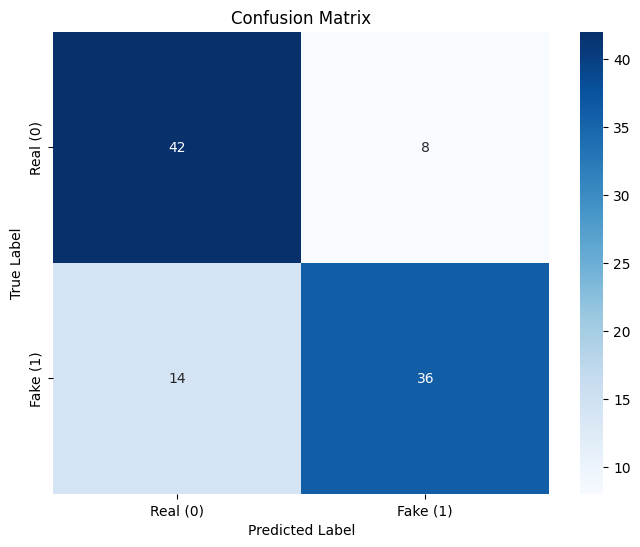

<Figure size 800x600 with 0 Axes>

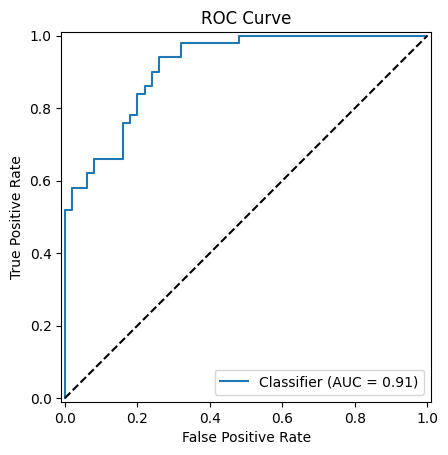

Model 1 - Metrics calculated and visualized.


In [16]:
batch_size = 32 # You can adjust this batch size based on your GPU memory
eval_dataloader = DataLoader(processed_dataset_model1, collate_fn=collate_fn, batch_size=batch_size, shuffle=False)

# Ensure model1 is in evaluation mode and on the correct device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1.to(device)
model1.eval()

true_labels = []
predicted_probs = []
predicted_labels = []

print("Starting evaluation...")

with torch.no_grad():
    for batch in eval_dataloader:
        if batch is None: # Skip empty batches
            continue

        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)

        outputs = model1(pixel_values)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)

        # Assuming binary classification, we want the probability of the positive class (fake, which is 1)
        # The `evaluate` library usually expects probabilities for the positive class for ROC-AUC.
        # If the model outputs (prob_class0, prob_class1), then prob_class1 is what we need.
        # We need to know which index corresponds to 'fake' label. Assuming 'fake' is 1.
        prob_of_fake = probabilities[:, 1].cpu().numpy()
        preds = torch.argmax(logits, dim=-1).cpu().numpy()

        true_labels.extend(labels.cpu().numpy())
        predicted_probs.extend(prob_of_fake)
        predicted_labels.extend(preds)

print("Evaluation complete. Calculating metrics...")

# Calculate metrics
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)
roc_auc = roc_auc_score(true_labels, predicted_probs)
conf_matrix = confusion_matrix(true_labels, predicted_labels)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Visualize ROC Curve
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(true_labels, predicted_probs)
plt.plot([0, 1], [0, 1], 'k--') # plot random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

print("Model 1 - Metrics calculated and visualized.")

Starting evaluation...
Evaluation complete. Calculating metrics...

Accuracy: 0.6400
Precision: 0.7917
Recall: 0.3800
F1-score: 0.5135
ROC-AUC: 0.7846


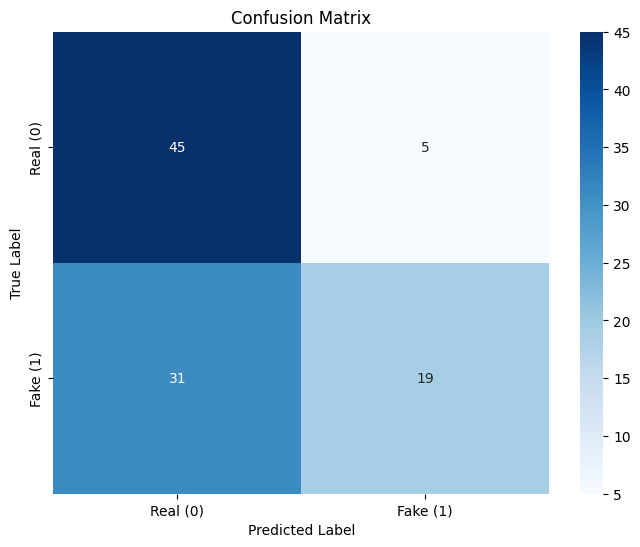

<Figure size 800x600 with 0 Axes>

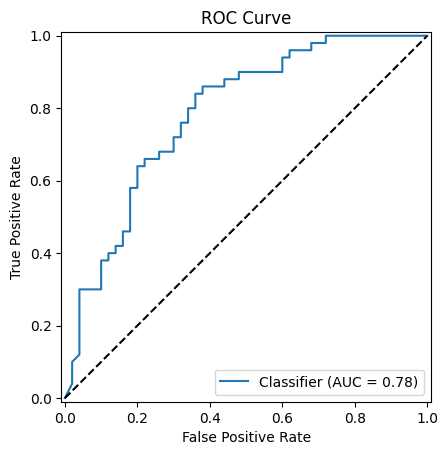

Model 2 - Metrics calculated and visualized.


In [17]:
batch_size = 32 # You can adjust this batch size based on your GPU memory
eval_dataloader = DataLoader(processed_dataset_model2, collate_fn=collate_fn, batch_size=batch_size, shuffle=False)

# Ensure model2 is in evaluation mode and on the correct device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2.to(device)
model2.eval()

true_labels = []
predicted_probs = []
predicted_labels = []

print("Starting evaluation...")

with torch.no_grad():
    for batch in eval_dataloader:
        if batch is None: # Skip empty batches
            continue

        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)

        outputs = model2(pixel_values)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)

        # Assuming binary classification, we want the probability of the positive class (fake, which is 1)
        # The `evaluate` library usually expects probabilities for the positive class for ROC-AUC.
        # If the model outputs (prob_class0, prob_class1), then prob_class1 is what we need.
        # We need to know which index corresponds to 'fake' label. Assuming 'fake' is 1.
        prob_of_fake = probabilities[:, 1].cpu().numpy()
        preds = torch.argmax(logits, dim=-1).cpu().numpy()

        true_labels.extend(labels.cpu().numpy())
        predicted_probs.extend(prob_of_fake)
        predicted_labels.extend(preds)

print("Evaluation complete. Calculating metrics...")

# Calculate metrics
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)
roc_auc = roc_auc_score(true_labels, predicted_probs)
conf_matrix = confusion_matrix(true_labels, predicted_labels)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Visualize ROC Curve
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(true_labels, predicted_probs)
plt.plot([0, 1], [0, 1], 'k--') # plot random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

print("Model 2 - Metrics calculated and visualized.")

Starting evaluation...
Evaluation complete. Calculating metrics...

Accuracy: 0.6700
Precision: 0.9048
Recall: 0.3800
F1-score: 0.5352
ROC-AUC: 0.8368


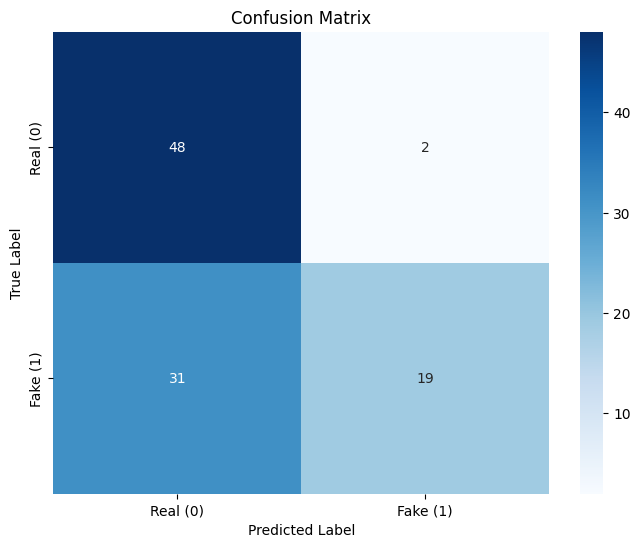

<Figure size 800x600 with 0 Axes>

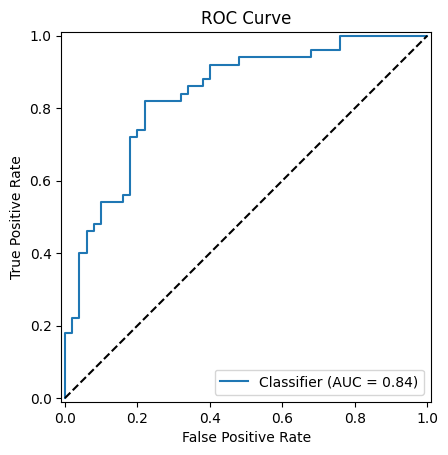

Model 3 - Metrics calculated and visualized.


In [18]:
batch_size = 32 # You can adjust this batch size based on your GPU memory
eval_dataloader = DataLoader(processed_dataset_model3, collate_fn=collate_fn, batch_size=batch_size, shuffle=False)

# Ensure model3 is in evaluation mode and on the correct device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model3.to(device)
model3.eval()

true_labels = []
predicted_probs = []
predicted_labels = []

print("Starting evaluation...")

with torch.no_grad():
    for batch in eval_dataloader:
        if batch is None: # Skip empty batches
            continue

        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)

        outputs = model3(pixel_values)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)

        # Assuming binary classification, we want the probability of the positive class (fake, which is 1)
        # The `evaluate` library usually expects probabilities for the positive class for ROC-AUC.
        # If the model outputs (prob_class0, prob_class1), then prob_class1 is what we need.
        # We need to know which index corresponds to 'fake' label. Assuming 'fake' is 1.
        prob_of_fake = probabilities[:, 1].cpu().numpy()
        preds = torch.argmax(logits, dim=-1).cpu().numpy()

        true_labels.extend(labels.cpu().numpy())
        predicted_probs.extend(prob_of_fake)
        predicted_labels.extend(preds)

print("Evaluation complete. Calculating metrics...")

# Calculate metrics
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)
roc_auc = roc_auc_score(true_labels, predicted_probs)
conf_matrix = confusion_matrix(true_labels, predicted_labels)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Visualize ROC Curve
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(true_labels, predicted_probs)
plt.plot([0, 1], [0, 1], 'k--') # plot random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

print("Model 3 - Metrics calculated and visualized.")